Two-planet systems
- Jupiter mass ratio, second planet between [1e-4 and 3e-4]
- Do different separations for a smaller planet wherever s produces a smaller caustic than the larger planet (s1 = 1.2, s2 = [0.2, 0.5, 0.8, 1/0.8. 1/0.5, 1/0.2])
- Angles = (0, 45, 90, 135, 180) degrees
- Shoot single planet maps with only Jupiter as well

In [2]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
q1 = 1e-3
s1 = 1.2
q2 = 3e-4
s2 = 0.2
alpha = 90

triple_lens_att_1 = np.array([
    [0, 0, 1], # Star at origin with mass 1
    [s1, 0, q1], # Big planet
    [s2*np.cos(np.radians(alpha)), s2*np.sin(np.radians(alpha)), q2] # Small planet at angle alpha
])

parameters = triple_lens_att_1.flatten().tolist()
VBM.SetLensGeometry(parameters)
caustics = VBM.Multicaustics() # Get caustics for the triple lens configuration
caustics = np.array(caustics, dtype=object)

caustic_big = VBM.Caustics(s1, q1) # Get caustics for the big planet alone
caustic_big = np.array(caustic_big, dtype=object)
caustic_small = VBM.Caustics(s2, q2) # Get caustics for the small planet alone
caustic_small = np.array(caustic_small, dtype=object)

center_of_mass_big = np.array([q1*s1 / (1 + q1), 0])
center_of_mass_small = np.array([q2*s2 / (1 + q2)*np.cos(np.radians(alpha)), q2*s2 / (1 + q2)*np.sin(np.radians(alpha))])

center_of_mass = np.average(triple_lens_att_1[:, :2], axis=0, weights=triple_lens_att_1[:, 2])
center_of_magnification = np.array([q2 / ((1 + q2) * (s1 + 1/s1)), 0])

triple_lens_att_1[:, :2] -= center_of_magnification

pixels, ang_width, (qs_list_1, ss_list_1), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(triple_lens_att_1, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')

pixels = 5000
ang_width = 0.4

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs=qs_list_1, ss=ss_list_1)
num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.5, r_theta_ratio=4)

print(f'Pixels: {pixels}')
print(f'Angular width: {ang_width}')
print(f'Minimum magnification: {min_mag}')
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, thickness = {y_plus - y_minus}')
print(f'Average radius of annulus: {(y_plus + y_minus)/2}')
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')
print(f'Maximum source radius: {max_source_radius}')
print(f'Minimum source radius: {min_source_radius}')

triple_lens_parameters_1 = {
    'lens_att': triple_lens_att_1.tolist(),
    'pixels': pixels,
    'ang_width': ang_width,
    'num_r': num_r,
    'num_theta': num_theta,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'thickness': y_plus - y_minus
}

q = 0.001, s = 1.2
q = 0.0003, s = 0.2
Pixels: 5000
Angular width: 0.4
Minimum magnification: 3.124220147531557
Annulus bounds: y+ = 1.1594573061918332, y- = 0.8619769040368946, thickness = 0.29748040215493854
Average radius of annulus: 1.010717105114364
Number of rays: num_r = 38876, num_theta = 9719
Total number of rays: 3.778e+08
Maximum source radius: 0.14876033057851246
Minimum source radius: 0.0014876033057851245


In [15]:
triple_sim_1 = IRSC.IRSCaustics(annulus_param_dict=triple_lens_parameters_1)
triple_magnifications_1 = triple_sim_1.series_calculate(cm_offset='auto', annulus_offset=center_of_magnification)

100%|██████████| 972/972 [00:08<00:00, 110.01it/s]


---------------------
Total time: 8.878 seconds


/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/Part 7/../../IRSMicroLensing/IRSCaustics.py:1300: RuntimeWarning: divide by zero encountered in log10
  magnifications_log_zoomed = np.log10(self.magnifications)[y_lower_bound:y_upper_bound, x_lower_bound:x_upper_bound]


Plotting magnification map: 0.358 seconds
Angular resolution: 8e-05


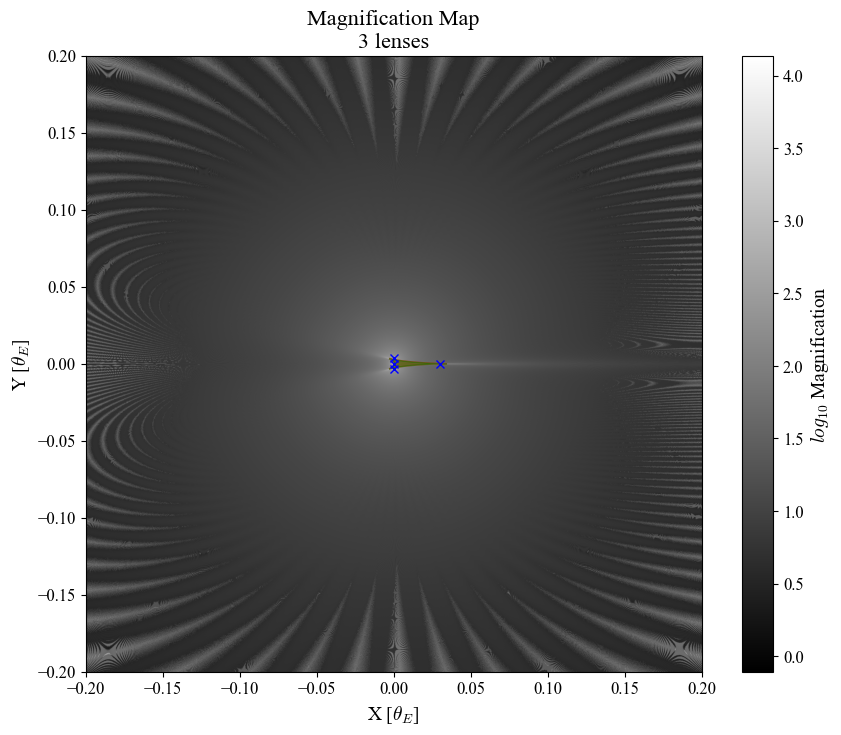

In [16]:
triple_sim_1.plot()
print(f'Angular resolution: {triple_sim_1.ang_res}')

for caustic in caustics:
    x = caustic[0] - center_of_magnification[0]
    y = caustic[1] - center_of_magnification[1]
    points = np.array([x, y]).T
    
    fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Caustics', facecolor='red', alpha=0.5)
    triple_sim_1.ax_c.add_patch(fpr)

for caustic in caustic_big:
    x = caustic[0] + center_of_mass_big[0] - center_of_magnification[0]
    y = caustic[1] + center_of_mass_big[1] - center_of_magnification[1]
    points = np.array([x, y]).T
    
    fpr2 = patches.Polygon(points, closed=False, fill=True, edgecolor='green', label='Big Planet Caustics', facecolor='green', alpha=0.5)
    triple_sim_1.ax_c.add_patch(fpr2)

for caustic in caustic_small:
    x = caustic[0] + center_of_mass_small[0] - center_of_magnification[0]
    y = caustic[1] + center_of_mass_small[1] - center_of_magnification[1]
    points = np.array([[np.cos(np.radians(alpha)), -np.sin(np.radians(alpha))], [np.sin(np.radians(alpha)), np.cos(np.radians(alpha))]]) @ np.array([x, y])
    
    fpr3 = patches.Polygon(points.T, closed=False, fill=True, edgecolor='blue', label='Small Planet Caustics', facecolor='blue', alpha=0.5)
    triple_sim_1.ax_c.add_patch(fpr3)

max_source_patch = patches.Circle((ang_width/2 - max_source_radius, 0), max_source_radius, fill=True, edgecolor='orange', facecolor='orange', alpha=0.5, linestyle='--', label='Max Source Size')
min_source_patch = patches.Circle((ang_width/2 - min_source_radius, 0), min_source_radius, fill=True, edgecolor='orange', facecolor='orange', alpha=0.5, linestyle='--', label='Min Source Size')

for cusp in cusp_points[0]:
    triple_sim_1.ax_c.plot(cusp[0], cusp[1], marker='x', color='blue', label='Cusp Points', linestyle='None')

# triple_sim_1.ax_c.add_patch(max_source_patch)
# triple_sim_1.ax_c.add_patch(min_source_patch)

# triple_sim_1.ax_c.set_xlim(-ang_width/100, ang_width/100)
# triple_sim_1.ax_c.set_ylim(-ang_width/100, ang_width/100)

# triple_sim_1.fig_c.savefig('./Figures/binary_lens_magnification_map.png', dpi=300)

# triple_sim_1.ax_c.legend(loc='upper right')

plt.show()

In [ ]:
with open('./Data Files/part_5_triple_attributes.csv', 'w') as f:
    ss_1_str = ['0.2', '0.6', '1.0', '1/0.6', '1/0.2']
    ss_1 = [numexpr.evaluate(s).astype(float) for s in ss_1_str]
    ss_2_str = ['0.2', '0.6', '1.0', '1/0.6', '1/0.2']
    ss_2 = [numexpr.evaluate(s).astype(float) for s in ss_2_str]
    q1 = 1e-3
    q2 = 3e-4
    alphas = [0, 45, 90, 135, 180]

    triple_attributes = []
    f.write('s1,s2,alpha,pixels,ang_width,num_r,num_theta,y_plus,y_minus,min_source_radius,max_source_radius\n')
    
    pixels = 5000
    ang_width = 0.2

    # Now, for each s in list, compute number of rays to fill up pixels while keeping pixels and angular width the same as for s = 0.9 and q = 1e-3
    for i, s1 in enumerate(ss_1):
        for j, s2 in enumerate(ss_2):
            for k, alpha in enumerate(alphas):
                print(f'\nCalculating for s1 = {s1}, s2 = {s2}, and alpha = {alpha}...')
                triple_lens_att = np.array([
                    [0, 0, 1], # Star at origin with mass 1
                    [s1, 0, q1], # Big planet
                    [s2*np.cos(np.radians(alpha)), s2*np.sin(np.radians(alpha)), q2] # Small planet at angle alpha
                ])

                if s1 != 1.0 and s2 != 1.0:
                    _, _, (qs_list, ss_list), points, (max_source_radius, min_source_radius) = _ang_width_calculator(triple_lens_att, cm_offset='auto', cm_translation=[0, 0], pixels_in_small_source=10)
                    (y_plus, y_minus), min_mag = _annulus_bounds_calculator(ang_width, qs=qs_list, ss=ss_list)
                    num_r, num_theta = _num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)

                print(f'Pixels: {pixels}')
                print(f'Angular width: {ang_width}')
                print(f'Minimum magnification: {min_mag}')
                print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, thickness = {y_plus - y_minus}')
                print(f'Average radius of annulus: {(y_plus + y_minus)/2}')
                print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
                print(f'Total number of rays: {(num_r * num_theta):.3e}')
                triple_attributes.append([ss_1_str[i], ss_2_str[j], alpha, pixels, ang_width, num_r, num_theta, y_plus, y_minus, min_source_radius, max_source_radius])
                f.write(f'{ss_1_str[i]},{ss_2_str[j]},{alpha},{pixels},{ang_width},{num_r},{num_theta},{y_plus},{y_minus},{min_source_radius},{max_source_radius}\n')
                print('=' * 50)


Calculating for s1 = 0.2, s2 = 0.2, and alpha = 0...
Pixels: 5000
Angular width: 0.2
Minimum magnification: 6.779269495063597
Annulus bounds: y+ = 1.0769986657270052, y- = 0.9285062613208713, thickness = 0.14849240440613387
Average radius of annulus: 1.0027524635239382
Number of rays: num_r = 1857080, num_theta = 464270
Total number of rays: 8.622e+11

Calculating for s1 = 0.2, s2 = 0.2, and alpha = 45...
Pixels: 5000
Angular width: 0.2
Minimum magnification: 6.779269495063597
Annulus bounds: y+ = 1.0769986657270052, y- = 0.9285062613208713, thickness = 0.14849240440613387
Average radius of annulus: 1.0027524635239382
Number of rays: num_r = 1857080, num_theta = 464270
Total number of rays: 8.622e+11

Calculating for s1 = 0.2, s2 = 0.2, and alpha = 90...
Pixels: 5000
Angular width: 0.2
Minimum magnification: 6.779269495063597
Annulus bounds: y+ = 1.0769986657270052, y- = 0.9285062613208713, thickness = 0.14849240440613387
Average radius of annulus: 1.0027524635239382
Number of rays: n